Dataset:
                                           text    category
0   Machine learning is useful for data science  Technology
1        Python is popular for machine learning  Technology
2  Data science uses statistics and programming  Technology
3           Football is a popular outdoor sport      Sports
4               Cricket is loved by many people      Sports
5           Sports improve fitness and teamwork      Sports
6      Artificial intelligence helps automation  Technology
7                 Deep learning is a part of AI  Technology
8                Tennis and football are sports      Sports

TF-IDF Feature Names:
['ai' 'artificial' 'automation' 'cricket' 'data' 'deep' 'fitness'
 'football' 'helps' 'improve' 'intelligence' 'learning' 'loved' 'machine'
 'outdoor' 'people' 'popular' 'programming' 'python' 'science' 'sport'
 'sports' 'statistics' 'teamwork' 'tennis' 'useful' 'uses']

TF-IDF Matrix Shape:
(9, 27)

Text Classification Accuracy:
0.6666666666666666

Classification R

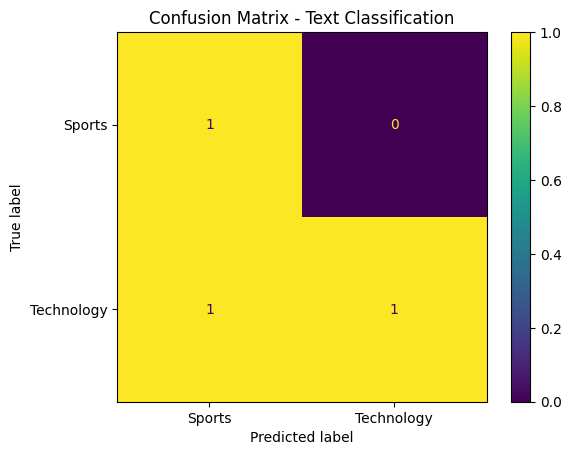


New Text:
Python and artificial intelligence are used in data science
Predicted Category:
Technology

Movie Dataset:
                     title                                        description
0            AI Revolution      Artificial intelligence and automation future
1     Python for Beginners               Learn Python programming from basics
2  Machine Learning Basics  Introduction to machine learning and data science
3       Football World Cup         Football tournament and sports competition
4        Cricket Champions          Cricket match analysis and sports players
5   Fitness Through Sports         Health fitness teamwork and outdoor sports
6      Deep Learning Guide  Neural networks deep learning artificial intel...
7    Data Science Handbook  Statistics machine learning Python and data sc...

Cosine Similarity Matrix:
title                    AI Revolution  Python for Beginners  \
title                                                          
AI Revolution            

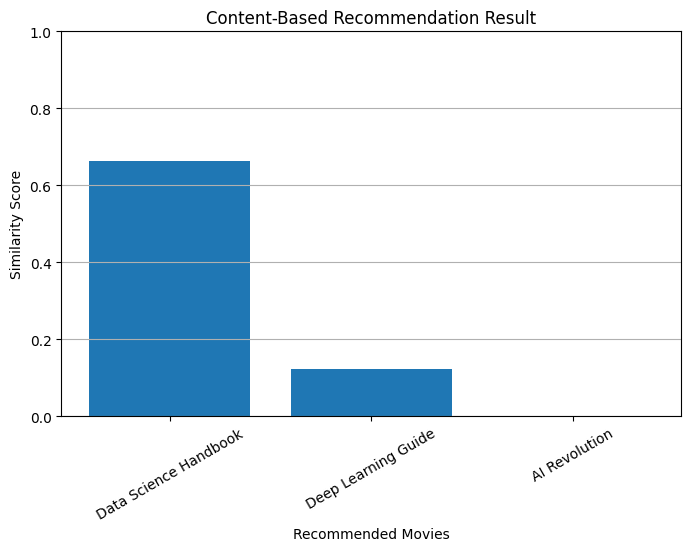


User-Movie Rating Matrix:
movie  AI Revolution  Cricket Champions  Deep Learning Guide  \
user                                                           
U1               5.0                0.0                  0.0   
U2               4.0                0.0                  5.0   
U3               0.0                4.0                  0.0   
U4               0.0                5.0                  0.0   

movie  Fitness Through Sports  Football World Cup  Machine Learning Basics  \
user                                                                         
U1                        0.0                 0.0                      5.0   
U2                        0.0                 0.0                      0.0   
U3                        0.0                 5.0                      0.0   
U4                        4.0                 0.0                      0.0   

movie  Python for Beginners  
user                         
U1                      4.0  
U2                      0.0  

In [1]:
# =====================================================
# TEXT ANALYTICS + RECOMMENDATION SYSTEM
# Beginner-Friendly Complete Python Implementation
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity


# -----------------------------------------------------
# PART 1: SAMPLE TEXT DATASET
# -----------------------------------------------------

data = {
    "text": [
        "Machine learning is useful for data science",
        "Python is popular for machine learning",
        "Data science uses statistics and programming",
        "Football is a popular outdoor sport",
        "Cricket is loved by many people",
        "Sports improve fitness and teamwork",
        "Artificial intelligence helps automation",
        "Deep learning is a part of AI",
        "Tennis and football are sports"
    ],
    "category": [
        "Technology",
        "Technology",
        "Technology",
        "Sports",
        "Sports",
        "Sports",
        "Technology",
        "Technology",
        "Sports"
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# -----------------------------------------------------
# PART 2: TEXT ANALYTICS USING TF-IDF
# -----------------------------------------------------

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["text"])
y = df["category"]

print("\nTF-IDF Feature Names:")
print(vectorizer.get_feature_names_out())

print("\nTF-IDF Matrix Shape:")
print(X.shape)


# -----------------------------------------------------
# PART 3: TEXT CLASSIFICATION USING NAIVE BAYES
# -----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nText Classification Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Text Classification")
plt.show()


# -----------------------------------------------------
# PART 4: PREDICT NEW TEXT
# -----------------------------------------------------

new_text = ["Python and artificial intelligence are used in data science"]

new_text_vector = vectorizer.transform(new_text)

prediction = model.predict(new_text_vector)

print("\nNew Text:")
print(new_text[0])

print("Predicted Category:")
print(prediction[0])


# -----------------------------------------------------
# PART 5: CONTENT-BASED RECOMMENDATION SYSTEM
# -----------------------------------------------------

movies = {
    "title": [
        "AI Revolution",
        "Python for Beginners",
        "Machine Learning Basics",
        "Football World Cup",
        "Cricket Champions",
        "Fitness Through Sports",
        "Deep Learning Guide",
        "Data Science Handbook"
    ],
    "description": [
        "Artificial intelligence and automation future",
        "Learn Python programming from basics",
        "Introduction to machine learning and data science",
        "Football tournament and sports competition",
        "Cricket match analysis and sports players",
        "Health fitness teamwork and outdoor sports",
        "Neural networks deep learning artificial intelligence",
        "Statistics machine learning Python and data science"
    ]
}

movies_df = pd.DataFrame(movies)

print("\nMovie Dataset:")
print(movies_df)


# Convert movie descriptions into TF-IDF vectors
movie_tfidf = vectorizer.fit_transform(movies_df["description"])

# Compute similarity between all movies
similarity_matrix = cosine_similarity(movie_tfidf)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=movies_df["title"],
    columns=movies_df["title"]
)

print("\nCosine Similarity Matrix:")
print(similarity_df)


# -----------------------------------------------------
# PART 6: RECOMMEND MOVIES
# -----------------------------------------------------

def recommend_movies(movie_title, top_n=3):
    if movie_title not in movies_df["title"].values:
        return "Movie not found"

    movie_index = movies_df[movies_df["title"] == movie_title].index[0]

    similarity_scores = list(enumerate(similarity_matrix[movie_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Exclude the same movie
    similarity_scores = similarity_scores[1:top_n + 1]

    recommendations = []

    for index, score in similarity_scores:
        recommendations.append({
            "Movie": movies_df.iloc[index]["title"],
            "Similarity Score": round(score, 3)
        })

    return pd.DataFrame(recommendations)


print("\nRecommendations for 'Machine Learning Basics':")
print(recommend_movies("Machine Learning Basics", 3))


# -----------------------------------------------------
# PART 7: RECOMMENDATION VISUALIZATION
# -----------------------------------------------------

recommended_df = recommend_movies("Machine Learning Basics", 3)

plt.figure(figsize=(8, 5))
plt.bar(
    recommended_df["Movie"],
    recommended_df["Similarity Score"]
)

plt.xlabel("Recommended Movies")
plt.ylabel("Similarity Score")
plt.title("Content-Based Recommendation Result")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()


# -----------------------------------------------------
# PART 8: SIMPLE COLLABORATIVE FILTERING
# -----------------------------------------------------

ratings = {
    "user": ["U1", "U1", "U1", "U2", "U2", "U3", "U3", "U4", "U4"],
    "movie": [
        "AI Revolution",
        "Python for Beginners",
        "Machine Learning Basics",
        "AI Revolution",
        "Deep Learning Guide",
        "Football World Cup",
        "Cricket Champions",
        "Fitness Through Sports",
        "Cricket Champions"
    ],
    "rating": [5, 4, 5, 4, 5, 5, 4, 4, 5]
}

ratings_df = pd.DataFrame(ratings)

user_movie_matrix = ratings_df.pivot_table(
    index="user",
    columns="movie",
    values="rating"
).fillna(0)

print("\nUser-Movie Rating Matrix:")
print(user_movie_matrix)

user_similarity = cosine_similarity(user_movie_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

print("\nUser Similarity Matrix:")
print(user_similarity_df)


def recommend_by_user_similarity(user_id):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)

    most_similar_user = similar_users.index[1]

    user_movies = set(
        ratings_df[ratings_df["user"] == user_id]["movie"]
    )

    similar_user_movies = set(
        ratings_df[ratings_df["user"] == most_similar_user]["movie"]
    )

    recommendations = similar_user_movies - user_movies

    return list(recommendations)


print("\nCollaborative Filtering Recommendation for U1:")
print(recommend_by_user_similarity("U1"))